## Protegrity Synthetic Data </H3>
Synthetic Data is a privacy-enhancing technology that generates artificial data from real datasets while preserving statistical properties and relationships without exposing actual personal information.

This Notebook provides an overview of Protegrity Synthetic Data.

It performs the following tasks:
- Demonstrates the value of Synthetic Data with training a Random Forest model on a Bank churn dataset.
- Generates a synthetic dataset with privacy guarantees.
- Presents a quality and privacy evaluations.

### Key Features

The following are the key features of the Protegrity Synthetic data.

- **Privacy-Preserving**: Ensures no connection to real individuals.
- **Statistically Accurate**: Preserves data relationships and distributions.
- **Customizable Filters**: Enables control of input and output through outlier removal, bias adjustments, and privacy thresholds.

For generating synthetic data, refer to the online documentation. For more information about REST APIs, refer to the <a href="http://localhost:8095/docs"> Swagger Doc </a>


### Data Sharing

The process for sharing data with vendors for AI Model building with and without Protegrity Synthetic Data is detailed here.

##### Without Protegrity Synthetic Data

The following figure illustrates sharing of data without Protegrity Synthetic Data.
- Either Sensitive data is anonymized or pseudonymized to protect privacy before sharing.
- Organizations provide vendors with API access to query the raw data securely.
- Create and convert test data.
![Image showing Data Sharing without Protegrity Synthetic Data](datashare_without_synth_data.png)

##### With Protegrity Synthetic Data

The following figure illustrates sharing of data with Protegrity Synthetic Data.
![Image showing Data Sharing with Protegrity Synthetic Data](datashare_with_synth_data.png)
<p>Organizations provide vendors governance compliant, privacy safe Synthetic Data.

### Step 1: Install & Import dependencies.

In [ ]:
%pip install pandas requests scikit-learn matplotlib tqdm seaborn protegrity-synthetic-data-sdk

/home/ubuntu/new_era/pty-ai-synthetic-data/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import requests
import json
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import time

from urllib3.exceptions import InsecureRequestWarning
from urllib3 import disable_warnings
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import seaborn as sns

disable_warnings(InsecureRequestWarning)
SERVICE_EP = "http://localhost:8000/pty/syntheticdata/v2"

### Step 2: Load and explore the data

Load a dataset and understand its structure and basic statistics.

In [2]:
def split_csv(path):
    df = pd.read_csv(path)
    train = df.sample(frac=0.8, random_state=42)
    test = df.drop(train.index)
    return train, test

In [3]:
source_file = "./datastore/bank_churn.csv"
train_df,test_df=split_csv(source_file)
display(train_df.head(),train_df.describe())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
6252,6253,15687492,Anderson,596,Germany,Male,32,3,96709.07,2,0,0,41788.37,0
4684,4685,15736963,Herring,623,France,Male,43,1,0.00,2,1,1,146379.30,0
1731,1732,15721730,Amechi,601,Spain,Female,44,4,0.00,2,1,0,58561.31,0
4742,4743,15762134,Liang,506,Germany,Male,59,8,119152.10,2,1,1,170679.74,0
4521,4522,15648898,Chuang,560,Spain,Female,27,7,124995.98,1,1,1,114669.79,0


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,8000.000000,8.000000e+03,8000.000000,8000.000000,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4989.523375,1.569113e+07,649.930250,38.969500,5.02925,76226.593497,1.534000,0.702375,0.514875,99458.750156,0.203375
std,2887.824119,7.230257e+04,96.756817,10.495086,2.89956,62377.396550,0.583641,0.457242,0.499810,57506.136366,0.402534
min,1.000000,1.556570e+07,350.000000,18.000000,0.00000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,2481.750000,1.562812e+07,583.000000,32.000000,3.00000,0.000000,1.000000,0.000000,0.000000,50397.985000,0.000000
50%,4979.500000,1.569058e+07,651.000000,37.000000,5.00000,97016.180000,1.000000,1.000000,1.000000,99594.475000,0.000000
75%,7500.250000,1.575399e+07,717.000000,44.000000,8.00000,127209.612500,2.000000,1.000000,1.000000,148087.685000,0.000000
max,10000.000000,1.581569e+07,850.000000,92.000000,10.00000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


### Step 3: Prepare the data for training

Perform the following actions:
- Remove unnecessary columns.
- Split into features (X) and target (y).
- Handle categorical variables.
- Split data into Training and Testing Sets.
- Use a Random Forest Classifier to train.
- Make Predictions using the trained model to predict outcomes on data it has never seen before.
- Measure how well model performed using various metrics.

In [4]:
def prepare_dataset(file_path):
    train_df, test_df = split_csv(file_path)
    # Drop unwanted columns
    cols_to_drop = ['RowNumber', 'CustomerId', 'Surname']
    train_df = train_df.drop(columns=cols_to_drop)
    test_df = test_df.drop(columns=cols_to_drop)

    X_train = train_df.drop('Exited', axis=1)
    y_train = train_df['Exited']
    X_test = test_df.drop('Exited', axis=1)
    y_test = test_df['Exited']

    # Convert categorical columns to dummy variables
    X_train = pd.get_dummies(X_train)
    X_test = pd.get_dummies(X_test)
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    return X_train,y_train,X_test,y_test

def fit_random_forest(X_train, y_train,X_test,y_test):
    clf = RandomForestClassifier(random_state=80)
    clf.fit(X_train, y_train)
    y_predict = clf.predict(X_test)

    from sklearn.metrics import classification_report
    rep=classification_report(y_test, y_predict,output_dict=True)
    return pd.DataFrame(rep).iloc[:-1, :].T

In [5]:
xt,yt,xT,yT=prepare_dataset(source_file)
metrics_src = fit_random_forest(xt,yt,xT,yT)
metrics_src

,precision,recall,f1-score
0,0.870034,0.964151,0.914678
1,0.760504,0.441463,0.558642
accuracy,0.857000,0.857000,0.857000
macro avg,0.815269,0.702807,0.736660
weighted avg,0.847580,0.857000,0.841690


### Step 4: Generate Synthetic Data
Generate artificial data from a real dataset using Protegrity Synthetic Data, which preserves statistical properties and relationships in data.

In [6]:
# ──────────────────────────────────────────────── Fit ────────────────────────────────────────────────────────────────────────
from synthetic_data_sdk.config import ClientConfig
from synthetic_data_sdk import RemoteVineCopula
config = ClientConfig(endpoint=SERVICE_EP)

# Drop identifier columns before fitting the copula model
synth_vine = RemoteVineCopula(config=config)
synth_vine.fit(train_df)
print("✓ VineCopula model fitted")

✓ VineCopula model fitted


In [8]:
# ──────────────────────────────────────────────── Transform ────────────────────────────────────────────────────────────────────────
# Step 4: Generate synthetic data
print("Generating synthetic data...")
synthetic = synth_vine.transform(n=1000)
print(f"✓ Generated {len(synthetic)} rows")

Generating synthetic data...


✓ Generated 1000 rows


In [9]:
print("Quick comparison:")
print(f"Age: Real={train_df['Age'].mean():.1f}, Synthetic={synthetic['Age'].mean():.1f}")
print(f"CreditScore: Real={train_df['CreditScore'].mean():.0f}, Synthetic={synthetic['CreditScore'].mean():.0f}")
print(f"EstimatedSalary: Real={train_df['EstimatedSalary'].mean():.0f}, Synthetic={synthetic['EstimatedSalary'].mean():.0f}")
print(f"Geography distribution matches: {set(train_df['Geography']) == set(synthetic['Geography'])}")

print("✓ Complete! Model saved for reuse.")

Quick comparison:
Age: Real=39.0, Synthetic=39.1
CreditScore: Real=650, Synthetic=644
EstimatedSalary: Real=99459, Synthetic=99376
Geography distribution matches: True
✓ Complete! Model saved for reuse.


### Step 5: Train on Synthetic Data
Train a Random Forest model on the generated synthetic data and evaluate it on the real test set to validate synthetic data quality.

In [10]:
# Prepare synthetic data for training, real data for testing
X_train_synth = synthetic.drop('Exited', axis=1)
y_train_synth = synthetic['Exited']

test_clean = test_df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
X_test_real = test_clean.drop('Exited', axis=1)
y_test_real = test_clean['Exited']

X_train_synth = pd.get_dummies(X_train_synth)
X_test_real = pd.get_dummies(X_test_real)
X_test_real = X_test_real.reindex(columns=X_train_synth.columns, fill_value=0)

metrics_predict_src_modeltrained_on_synth = fit_random_forest(X_train_synth, y_train_synth, X_test_real, y_test_real)
metrics_predict_src_modeltrained_on_synth

,precision,recall,f1-score
0,0.818915,0.958491,0.883222
1,0.525180,0.178049,0.265938
accuracy,0.798500,0.798500,0.798500
macro avg,0.672047,0.568270,0.574580
weighted avg,0.758699,0.798500,0.756679


### Step 6: Visualize Results
<p>Comparison of Source vs Synthetic Data Performance in Random Forest Fit

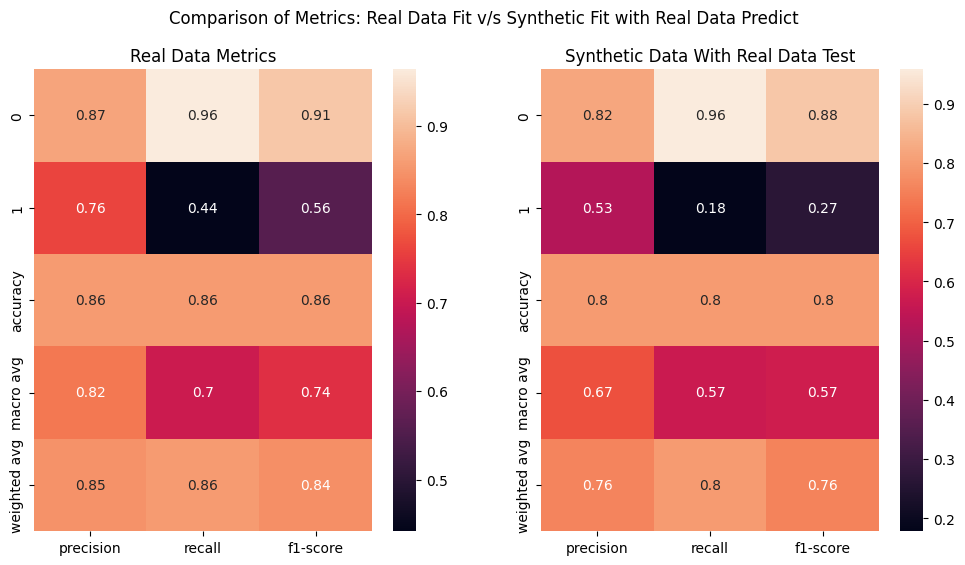

In [11]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12, 6))
fig.suptitle('Comparison of Metrics: Real Data Fit v/s Synthetic Fit with Real Data Predict')
ax1.set_title('Real Data Metrics')
ax2.set_title('Synthetic Data With Real Data Test')

sns.heatmap(metrics_src, ax=ax1,annot=True)
sns.heatmap(metrics_predict_src_modeltrained_on_synth, ax=ax2,annot=True)
plt.show()

In [22]:
# Generate more data and save the generated synthetic data for future use.
#synthetic=synth_vine.transform(n=1000)
#synthetic.to_csv("synthetic_data.csv")